# Digital Signals Theory

In [1]:
%matplotlib inline

import matplotlib.pyplot as plt
import numpy as np
import soundfile as sf

from IPython.display import display, Audio

## Chapter 10: Frequency domain convolution

#### Example 10.1 (Discarding phase)

[Drums Breakbeat 1.wav](https://freesound.org/people/RutgerMuller/sounds/50712/)

In [2]:
wav = "bin/50712__rutgermuller__drums-breakbeat-1.wav"

In [3]:
file_info = sf.info(wav)
file_info

bin/50712__rutgermuller__drums-breakbeat-1.wav
samplerate: 44100 Hz
channels: 1
duration: 12.077 s
format: WAV (Microsoft) [WAV]
subtype: Signed 16 bit PCM [PCM_16]

In [4]:
x, fs = sf.read(wav)
t = np.arange(len(x)) / fs

display('signal x: Drums Breakbeat 1.wav')
display(Audio(data=x, rate=fs))

'signal x: Drums Breakbeat 1.wav'

In [5]:
# take the DFT of the original signal...
X = np.fft.rfft(x)

# discard the phase component...
Y = np.abs(X)

# invert this DFT to get a new signal!
y = np.fft.irfft(Y)

In [6]:
display('signal x with no phase component')
display(Audio(data=y, rate=fs))

'signal x with no phase component'

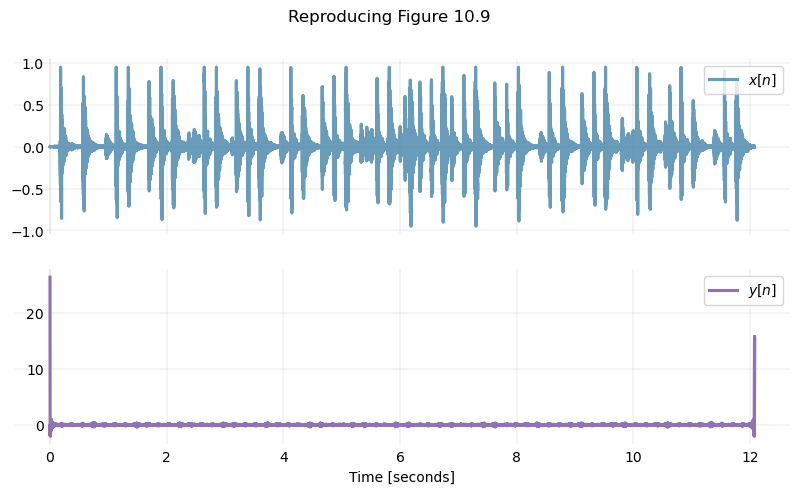

In [18]:
fig, axes = plt.subplots(nrows=2, ncols=1, figsize=(10, 5))

# 1st plot for x in Time domain...
axes[0].plot(t, x, linewidth=2.25, color='#045a8d', alpha=0.6, zorder=-1, label='$x[n]$')

axes[0].grid(True, linewidth=0.3, color='grey', alpha=0.4)
#axes[0].set_title('Signal $x[n]$')
# Eliminate upper and right axes
axes[0].spines['right'].set_color('none')
axes[0].spines['top'].set_color('none')

# Move left y-axis, passing through (0,0)
axes[0].spines['left'].set_position('zero')
axes[0].spines['left'].set_color('grey')
axes[0].spines['left'].set_alpha(0.4)
axes[0].spines['left'].set_linewidth(0.3)
# Leave bottom x-axis, passing through center of plot
axes[0].spines['bottom'].set_color('#f7f7f7')
axes[0].spines['bottom'].set_alpha(0.4)
axes[0].spines['bottom'].set_linewidth(0.3)
axes[0].set_xlabel(None)
#axes[0].xaxis.set_label_coords(0.5, -0.09)
axes[0].set_xticks([0,2,4,6,8,10,12], [])
axes[0].tick_params(left=False, bottom=False, pad=1)
axes[0].legend(loc='upper right')

# 2nd plot for x in Time domain...
axes[1].plot(t, y, linewidth=2.25, color='#4a1486', alpha=0.6, zorder=-1, label='$y[n]$')

axes[1].grid(True, linewidth=0.3, color='grey', alpha=0.4)
#axes[1].set_title('Signal $y[n]$')
# Eliminate upper and right axes
axes[1].spines['right'].set_color('none')
axes[1].spines['top'].set_color('none')

# Move left y-axis, passing through (0,0)
axes[1].spines['left'].set_position('zero')
axes[1].spines['left'].set_color('grey')
axes[1].spines['left'].set_alpha(0.4)
axes[1].spines['left'].set_linewidth(0.3)
# Leave bottom x-axis, passing through center of plot
axes[1].spines['bottom'].set_color('#f7f7f7')
axes[1].spines['bottom'].set_alpha(0.4)
axes[1].spines['bottom'].set_linewidth(0.3)
axes[1].set_xlabel('Time [seconds]')
axes[1].tick_params(left=False, bottom=False, pad=1)
axes[1].legend(loc='upper right')

plt.suptitle("Reproducing Figure 10.9")
plt.show()

> Discarding phase information preserves some aspects of the (original) signal... the same frequencies are generally present... but the temporal coherence of the (original) signal has been destroyed.